In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
# Cargar dataset
digits = load_digits()
X, y = digits.data, digits.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [7]:
# 1. Entrenamos el Árbol de Decisión individual
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test) # Guardamos la predicción para comparar
acc_tree = accuracy_score(y_test, y_pred_tree)

# 2. Entrenamos el Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test) # <--- ESTO es lo que faltaba para que no de error después
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy Árbol de Decisión: {acc_tree:.4f}")
print(f"Accuracy Random Forest: {acc_rf:.4f}")

Accuracy Árbol de Decisión: 0.8426
Accuracy Random Forest: 0.9759


In [8]:
print("REPORTE CLASIFICACIÓN - RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

REPORTE CLASIFICACIÓN - RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.96      1.00      0.98        50
           2       1.00      1.00      1.00        47
           3       0.98      0.96      0.97        54
           4       0.97      1.00      0.98        60
           5       0.97      0.95      0.96        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       0.95      0.95      0.95        43
           9       0.97      0.95      0.96        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



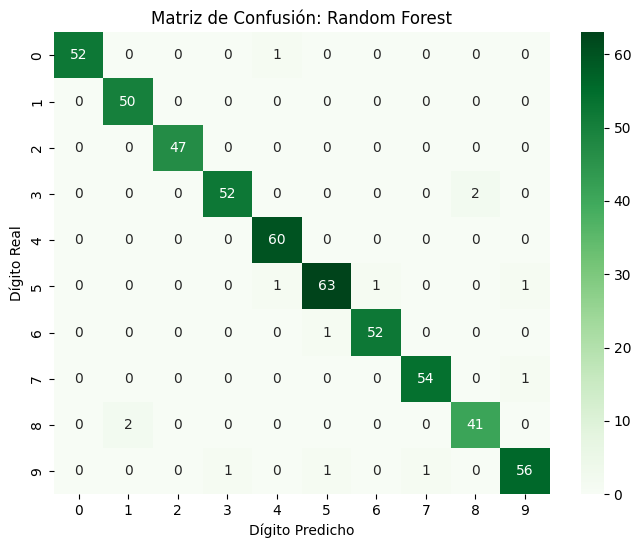

In [9]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión: Random Forest')
plt.ylabel('Dígito Real')
plt.xlabel('Dígito Predicho')
plt.show()

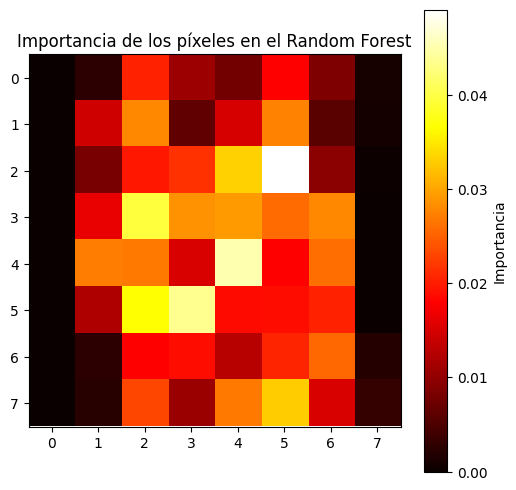

In [10]:
importances = rf.feature_importances_.reshape(8, 8) # Lo pasamos a 8x8 para verlo como el dígito
plt.figure(figsize=(6,6))
plt.imshow(importances, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importancia')
plt.title('Importancia de los píxeles en el Random Forest')
plt.show()